In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
pd.set_option('display.max_columns', None)

In [2]:
# Carga de datasets

df_hr_limpio = pd.read_csv('../df_hr_limpio.csv')

In [3]:
## para ver por que la gente se va se me ocurre que tendriamos que ver 


# comparar los empleados que se han ido, con los que se han quedado, para ver si hay alguna diferencia entre ellos:
# - si eran hombres o mujeres CAROL
# - si llevaban mucho tiempo con el mismo responsable o si es el mismo responsable el de todos los que se van CAROL
# - WorkLifeBalance CAROL

### 1) comparar los empleados que se han ido, con los que se han quedado, para ver si hay alguna diferencia entre ellos:
### - Si viajaban mucho o no ?

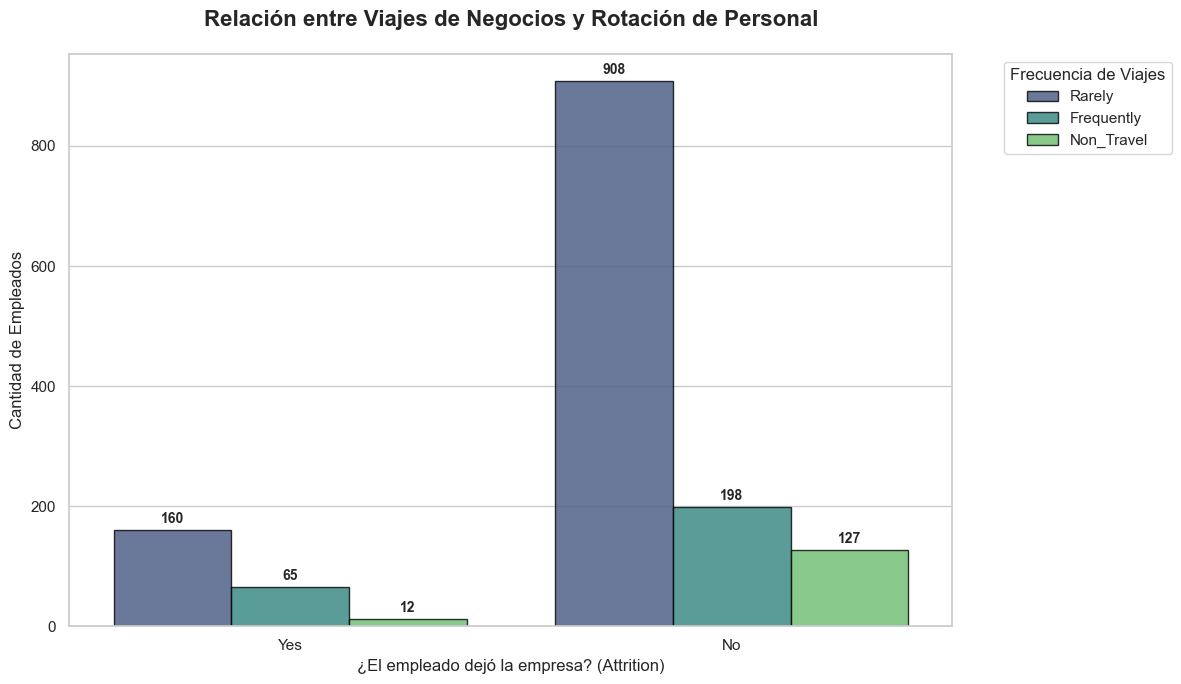

In [5]:

# Configurar el estilo visual desde el inicio
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# Crear el gráfico con una paleta de colores más moderna
ax = sns.countplot(
    data=df_hr_limpio, 
    x='attrition', 
    hue='business_travel', 
    palette='viridis',  # O 'magma' para un look más serio
    edgecolor='black',
    alpha=0.8
)

# --- MEJORAS CLAVE ---

# 1. Añadir etiquetas de datos (frecuencia) sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

# 2. Título y etiquetas más descriptivos
plt.title('Relación entre Viajes de Negocios y Rotación de Personal', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('¿El empleado dejó la empresa? (Attrition)', fontsize=12)
plt.ylabel('Cantidad de Empleados', fontsize=12)

# 3. Personalizar los nombres de los ejes (si son 0/1 o No/Yes)
# ax.set_xticklabels(['Se Quedan', 'Se Van']) # Descomenta si necesitas renombrar

# 4. Mejorar la leyenda para que no estorbe
plt.legend(title='Frecuencia de Viajes', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# 5. Ajuste final de layout para que no se corte nada
plt.tight_layout()

plt.show()

### 1) comparar los empleados que se han ido, con los que se han quedado, para ver si hay alguna diferencia entre ellos:
### - Impacto del Tiempo desde el Último Ascenso en la Rotación' ? YearsSinceLastPromotion

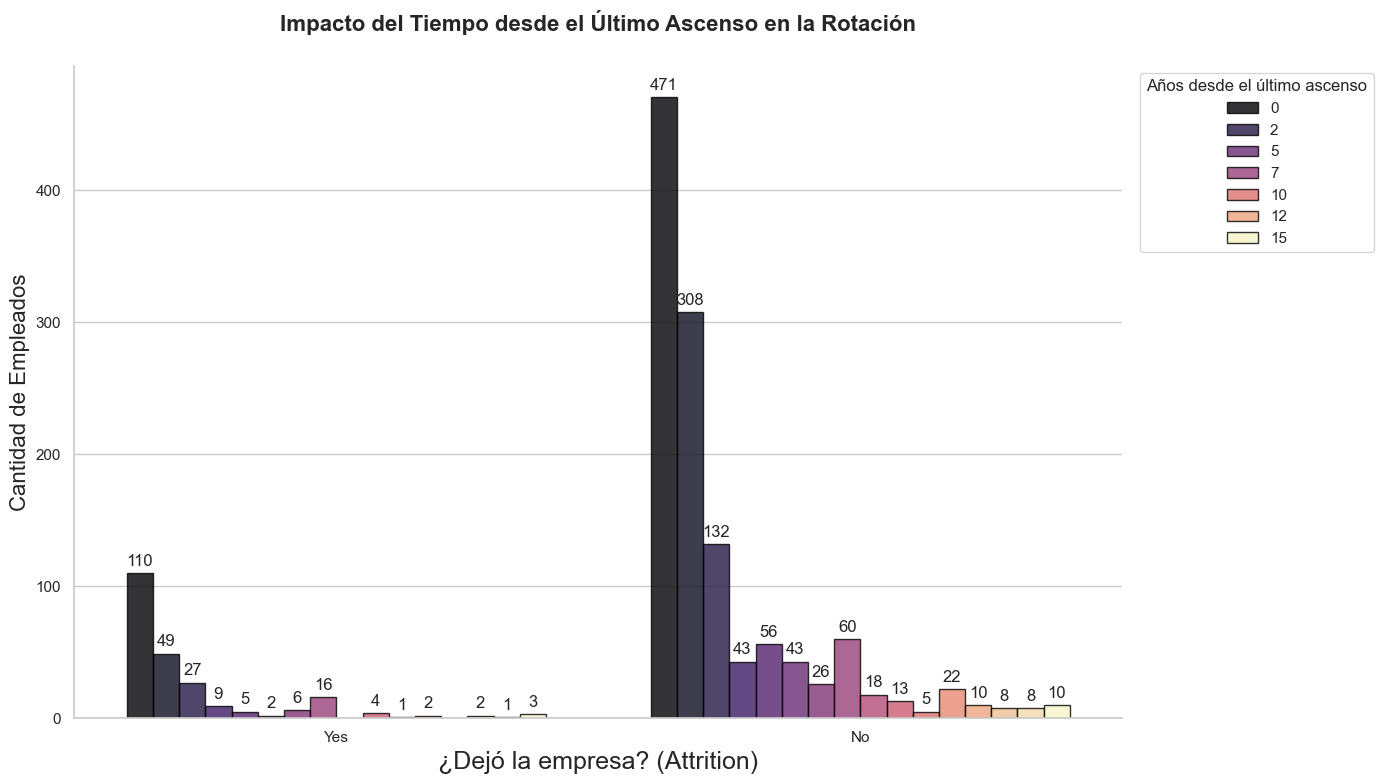

In [13]:
# Configurar el estilo
sns.set_theme(style="whitegrid")

# Aumentamos un poco el ancho (14) porque habrá muchas más barras por categoría
plt.figure(figsize=(14, 8))

# Crear el gráfico
ax = sns.countplot(
    data=df_hr_limpio, 
    x='attrition', 
    hue='years_since_last_promotion', 
    palette='magma',  # 'magma' ayuda a ver mejor la progresión numérica
    edgecolor='black',
    alpha=0.8
)

# --- MEJORAS ESPECÍFICAS ---

# 1. Etiquetas de datos (solo si el número es mayor a 0 para no ensuciar)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=12)

# 2. Títulos y ejes
plt.title('Impacto del Tiempo desde el Último Ascenso en la Rotación', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('¿Dejó la empresa? (Attrition)', fontsize=18)
plt.ylabel('Cantidad de Empleados', fontsize=16)

# 3. Ajuste de la leyenda
# Como hay muchos años, la movemos a la derecha para que no tape las barras
plt.legend(title='Años desde el último ascenso', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1)

# 4. Limpieza visual
sns.despine() # Quita los marcos innecesarios
plt.tight_layout()

plt.show()

### 1) comparar los empleados que se han ido, con los que se han quedado, para ver si hay alguna diferencia entre ellos:
### - stock_option_level se refiere al nivel de opciones sobre acciones que la compañía ofrece a un empleado como parte de su compensación. Ver si los que dimitieron tenian acciones

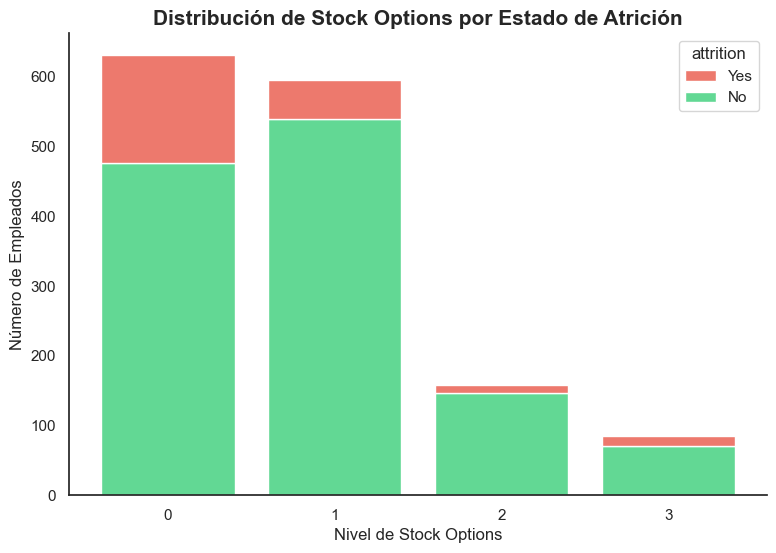

In [21]:
plt.figure(figsize=(9, 6))

# El histplot es ideal para ver distribuciones
sns.histplot(
    data=df_hr_limpio, 
    x='stock_option_level', 
    hue='attrition', 
    multiple='stack',      # Apila las barras para ver el total y la parte que se va
    palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, # Rojo para fuga, Verde para permanencia
    shrink=0.8,            # Deja un poco de espacio entre barras para que se vea limpio
    discrete=True          # Al ser niveles 0,1,2,3, le decimos que son valores discretos
)

# Mejoras visuales
plt.title('Distribución de Stock Options por Estado de Atrición', fontsize=15, fontweight='bold')
plt.xlabel('Nivel de Stock Options', fontsize=12)
plt.ylabel('Número de Empleados', fontsize=12)
plt.xticks([0, 1, 2, 3]) # Aseguramos que solo se vean los niveles reales

# Limpiamos el borde superior y derecho
sns.despine()

plt.show()